In [1]:
import json

candidates = []

with open("F:\\autorecruit-\\data_forensic _files\\candidates.jsonl", "r", encoding="utf-8") as f:
    for line in f:
        candidates.append(json.loads(line))
        
# print(json.dumps(candidates[4],indent=4))

In [2]:
print(json.dumps(candidates[4],indent=4))

{
    "candidate_id": "CAND_0000005",
    "profile": {
        "anonymized_name": "Aisha Sethi",
        "headline": "Accountant | Helping teams scale",
        "summary": "Professional with 11.0+ years of experience. I've spent my career in marketing manager roles, mostly focused on driving outcomes through process, people, and customer relationships. Lately I've been curious about how AI tools could augment my work \u2014 I've experimented with ChatGPT and a few other tools for productivity and content creation, and I think the space is exciting. Open to roles where I can apply my domain expertise alongside emerging AI capabilities.",
        "location": "Gurgaon, Haryana",
        "country": "India",
        "years_of_experience": 11.0,
        "current_title": "Accountant",
        "current_company": "Stark Industries",
        "current_company_size": "1001-5000",
        "current_industry": "Manufacturing"
    },
    "career_history": [
        {
            "company": "Stark Indu

In [3]:
print(json.dumps(list(candidates[0].keys()), indent=4))

[
    "candidate_id",
    "profile",
    "career_history",
    "education",
    "skills",
    "certifications",
    "languages",
    "redrob_signals"
]


In [4]:
print(json.dumps(list(candidates[0]["profile"].keys()), indent=4))

[
    "anonymized_name",
    "headline",
    "summary",
    "location",
    "country",
    "years_of_experience",
    "current_title",
    "current_company",
    "current_company_size",
    "current_industry"
]


In [5]:
print(json.dumps(list(candidates[0]["redrob_signals"].keys()), indent=4))

[
    "profile_completeness_score",
    "signup_date",
    "last_active_date",
    "open_to_work_flag",
    "profile_views_received_30d",
    "applications_submitted_30d",
    "recruiter_response_rate",
    "avg_response_time_hours",
    "skill_assessment_scores",
    "connection_count",
    "endorsements_received",
    "notice_period_days",
    "expected_salary_range_inr_lpa",
    "preferred_work_mode",
    "willing_to_relocate",
    "github_activity_score",
    "search_appearance_30d",
    "saved_by_recruiters_30d",
    "interview_completion_rate",
    "offer_acceptance_rate",
    "verified_email",
    "verified_phone",
    "linkedin_connected"
]


In [6]:
import pandas as pd

profiles = []

for c in candidates:
    p = c["profile"]

    profiles.append({
        "candidate_id": c["candidate_id"],
        "name": p["anonymized_name"],
        "headline": p["headline"],
        "location": p["location"],
        "country": p["country"],
        "experience": p["years_of_experience"],
        "title": p["current_title"]
    })

profiles_df = pd.DataFrame(profiles)

# profiles_df.head()
profiles_df

,candidate_id,name,headline,location,country,experience,title
0,CAND_0000001,Ira Vora,"Backend Engineer | SQL, Spark, Cloud",Toronto,Canada,6.9,Backend Engineer
1,CAND_0000002,Saanvi Sethi,Operations Manager | 12.5+ yrs experience,"Chennai, Tamil Nadu",India,12.5,Operations Manager
2,CAND_0000003,Yash Agarwal,Customer Support | 1.1+ yrs experience,Austin,USA,1.1,Customer Support
3,CAND_0000004,Anil Bose,Marketing Manager | Driving business outcomes,Sydney,Australia,3.8,Marketing Manager
4,CAND_0000005,Aisha Sethi,Accountant | Helping teams scale,"Gurgaon, Haryana",India,11.0,Accountant
...,...,...,...,...,...,...,...
99995,CAND_0099996,Myra Sethi,Operations Manager | 13.4+ yrs experience,"Ahmedabad, Gujarat",India,13.4,Operations Manager
99996,CAND_0099997,Priya Krishnan,Mechanical Engineer | 10.6+ yrs experience,"Bangalore, Karnataka",India,10.6,Mechanical Engineer
99997,CAND_0099998,Shreya Agarwal,Analytics Engineer | 7.3+ yrs in data engineering,"Kochi, Kerala",India,7.3,Analytics Engineer
99998,CAND_0099999,Diya Menon,.NET Developer | Backend systems & APIs,"Bhubaneswar, Odisha",India,4.3,.NET Developer


In [7]:
countries = [r["profile"]["country"] for r in candidates]

print(pd.Series(countries).value_counts())

percentage_wise = pd.Series(countries).value_counts()*100/len(countries)

percentage_wise
    
# print("total_country_wise_count: ", pd.Series(countries).value_counts()

India        75113
USA           9978
Australia     2579
Canada        2506
UK            2472
Germany       2469
Singapore     2453
UAE           2430
Name: count, dtype: int64


India        75.113
USA           9.978
Australia     2.579
Canada        2.506
UK            2.472
Germany       2.469
Singapore     2.453
UAE           2.430
Name: count, dtype: float64

In [8]:
locations = [
    (r["profile"]["location"], r["profile"]["country"])
    # r["profile"]["country"]
    for r in candidates
]

location_counts = pd.Series(locations).value_counts()
location_counts_percentage = location_counts * 100 / len(candidates)
location_counts_percentage

(Bhubaneswar, Odisha, India)       4.321
(Hyderabad, Telangana, India)      4.283
(Noida, Uttar Pradesh, India)      4.283
(Jaipur, Rajasthan, India)         4.268
(Bangalore, Karnataka, India)      4.238
(Kolkata, West Bengal, India)      4.230
(Indore, Madhya Pradesh, India)    4.198
(Pune, Maharashtra, India)         4.186
(Chennai, Tamil Nadu, India)       4.164
(Delhi, Delhi, India)              4.161
(Trivandrum, Kerala, India)        4.151
(Ahmedabad, Gujarat, India)        4.143
(Chandigarh, Chandigarh, India)    4.128
(Coimbatore, Tamil Nadu, India)    4.113
(Vizag, Andhra Pradesh, India)     4.093
(Kochi, Kerala, India)             4.073
(Mumbai, Maharashtra, India)       4.043
(Gurgaon, Haryana, India)          4.037
(Sydney, Australia)                2.579
(San Francisco, USA)               2.536
(Austin, USA)                      2.531
(New York, USA)                    2.518
(Toronto, Canada)                  2.506
(London, UK)                       2.472
(Berlin, Germany

In [9]:
experience = [r["profile"]["years_of_experience"] for r in candidates]
experience_counts = pd.Series(experience)
experience_counts_percentage = experience_counts * 100 / len(candidates)

print(experience_counts.value_counts())

print("Mean : ", experience_counts.mean())
print("Median : ", experience_counts.median())
print("Max : ", experience_counts.max())
print("Min : ", experience_counts.min())

4.8     943
3.6     929
3.2     925
7.5     918
7.4     916
       ... 
16.9      1
16.5      1
16.6      1
16.1      1
15.6      1
Name: count, Length: 148, dtype: int64
Mean :  7.1663190000000005
Median :  6.8
Max :  16.9
Min :  1.0


In [10]:
titles = [
    r["profile"]["current_title"] for r in candidates
]
title_counts = pd.Series(titles)
print(title_counts.value_counts())

title_percentage = title_counts.value_counts() * 100 / len(candidates)
title_percentage

Business Analyst                    5833
HR Manager                          5830
Mechanical Engineer                 5791
Accountant                          5764
Project Manager                     5754
Customer Support                    5750
Operations Manager                  5744
Content Writer                      5727
Sales Executive                     5713
Civil Engineer                      5702
Graphic Designer                    5689
Marketing Manager                   5524
Software Engineer                   3450
Full Stack Developer                2873
Cloud Engineer                      2836
Java Developer                      2809
.NET Developer                      2788
DevOps Engineer                     2787
Mobile Developer                    2757
Frontend Engineer                   2738
QA Engineer                         2682
Analytics Engineer                   764
Data Engineer                        744
Data Analyst                         728
Backend Engineer

Business Analyst                    5.833
HR Manager                          5.830
Mechanical Engineer                 5.791
Accountant                          5.764
Project Manager                     5.754
Customer Support                    5.750
Operations Manager                  5.744
Content Writer                      5.727
Sales Executive                     5.713
Civil Engineer                      5.702
Graphic Designer                    5.689
Marketing Manager                   5.524
Software Engineer                   3.450
Full Stack Developer                2.873
Cloud Engineer                      2.836
Java Developer                      2.809
.NET Developer                      2.788
DevOps Engineer                     2.787
Mobile Developer                    2.757
Frontend Engineer                   2.738
QA Engineer                         2.682
Analytics Engineer                  0.764
Data Engineer                       0.744
Data Analyst                      

In [11]:
companies = [
    r["profile"]["current_company"] for r in candidates
]

company_counts = pd.Series(companies)
company_counts.value_counts()
# print(company_counts.value_counts())

Infosys              7590
Wayne Enterprises    7571
Wipro                7566
Initech              7528
Pied Piper           7500
                     ... 
LinkedIn                4
Salesforce              4
Apple                   2
Adobe                   2
Uber                    1
Name: count, Length: 63, dtype: int64

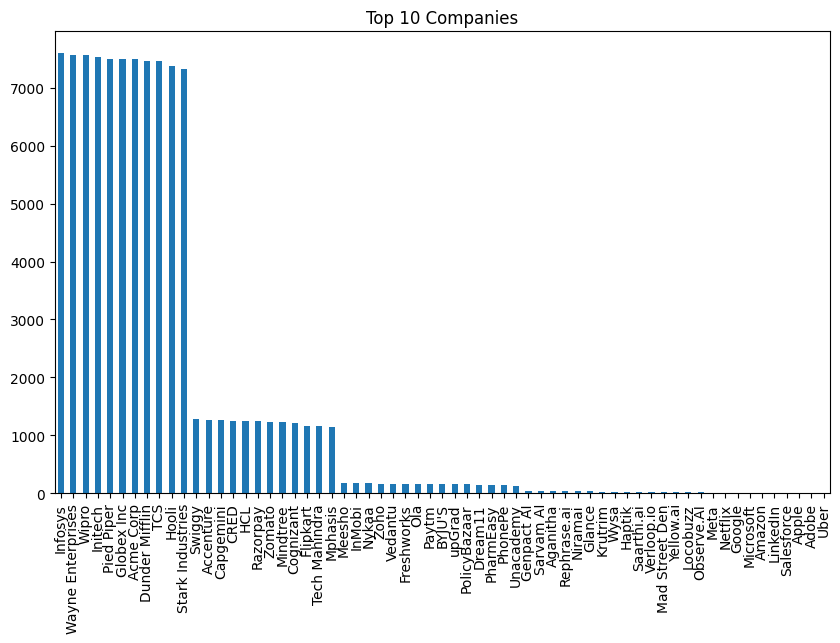

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
company_counts.value_counts().plot(kind="bar")
plt.title("Top 10 Companies")
plt.show()

In [13]:
industries = [
    r["profile"]["current_industry"] for r in candidates
]

industry_counts = pd.Series(industries)
print(industry_counts.value_counts())

industry_counts_percentage = industry_counts.value_counts() * 100 / len(candidates)
industry_counts_percentage

IT Services             29881
Software                22417
Manufacturing           22305
Conglomerate             7571
Paper Products           7467
Fintech                  2808
Food Delivery            2514
E-commerce               1529
Consulting               1274
EdTech                    610
SaaS                      328
AI/ML                     278
AdTech                    172
Transportation            162
Insurance Tech            155
Gaming                    149
HealthTech                147
HealthTech AI              68
Conversational AI          62
AI Services                42
Voice AI                   31
Internet                   22
Media                       6
Consumer Electronics        2
Name: count, dtype: int64


IT Services             29.881
Software                22.417
Manufacturing           22.305
Conglomerate             7.571
Paper Products           7.467
Fintech                  2.808
Food Delivery            2.514
E-commerce               1.529
Consulting               1.274
EdTech                   0.610
SaaS                     0.328
AI/ML                    0.278
AdTech                   0.172
Transportation           0.162
Insurance Tech           0.155
Gaming                   0.149
HealthTech               0.147
HealthTech AI            0.068
Conversational AI        0.062
AI Services              0.042
Voice AI                 0.031
Internet                 0.022
Media                    0.006
Consumer Electronics     0.002
Name: count, dtype: float64

In [40]:
skills = []

for c in candidates:

    for skill in c["skills"]:

        skills.append({
            "candidate_id": c["candidate_id"],
            "skill": skill["name"],
            "proficiency": skill["proficiency"],
            "endorsements": skill["endorsements"],
            "duration_months": skill["duration_months"]
        })

skills_df = pd.DataFrame(skills)

print(skills_df["skill"].unique())
print("\n", "Skills_in_total : ", skills_df["skill"].unique().size)

with pd.option_context('display.max_rows', None):
    print("",skills_df["skill"].value_counts().head(50))
    print(skills_df['skill'].value_counts())

['Tailwind' 'NLP' 'Image Classification' 'Fine-tuning LLMs'
 'Weights & Biases' 'Speech Recognition' 'Photoshop' 'TTS' 'LoRA'
 'Apache Beam' 'AWS' 'Flask' 'BentoML' 'Milvus' 'GANs'
 'Statistical Modeling' 'GCP' 'Project Management' 'React' 'TypeScript'
 'Marketing' 'Kafka' 'JavaScript' 'Feature Engineering' 'Angular' 'SEO'
 'Excel' 'Accounting' 'Kubernetes' 'Databricks' 'Node.js'
 'Content Writing' 'Redux' 'Airflow' 'GraphQL' 'Object Detection'
 'Webpack' 'Six Sigma' 'SAP' 'SQL' 'PowerPoint' 'Apache Flink' 'Sales'
 'gRPC' 'Django' 'Terraform' 'MongoDB' 'Spark' 'Scrum' 'Illustrator'
 'Java' 'BigQuery' 'Rust' 'HTML' 'Snowflake' 'OpenCV' 'Go' 'Spring Boot'
 'Kubeflow' 'Figma' 'Elasticsearch' 'CNN' 'Azure' 'Prompt Engineering'
 'MLOps' 'Python' 'BM25' 'Recommendation Systems' 'FastAPI'
 'Hugging Face Transformers' 'PostgreSQL' 'Vue.js' 'dbt' 'Agile'
 'Data Pipelines' 'FAISS' 'OpenSearch' 'YOLO' 'REST APIs' 'PyTorch'
 'Qdrant' 'Computer Vision' 'Next.js' 'Tally' 'Hadoop' 'Salesforce CRM'
 '

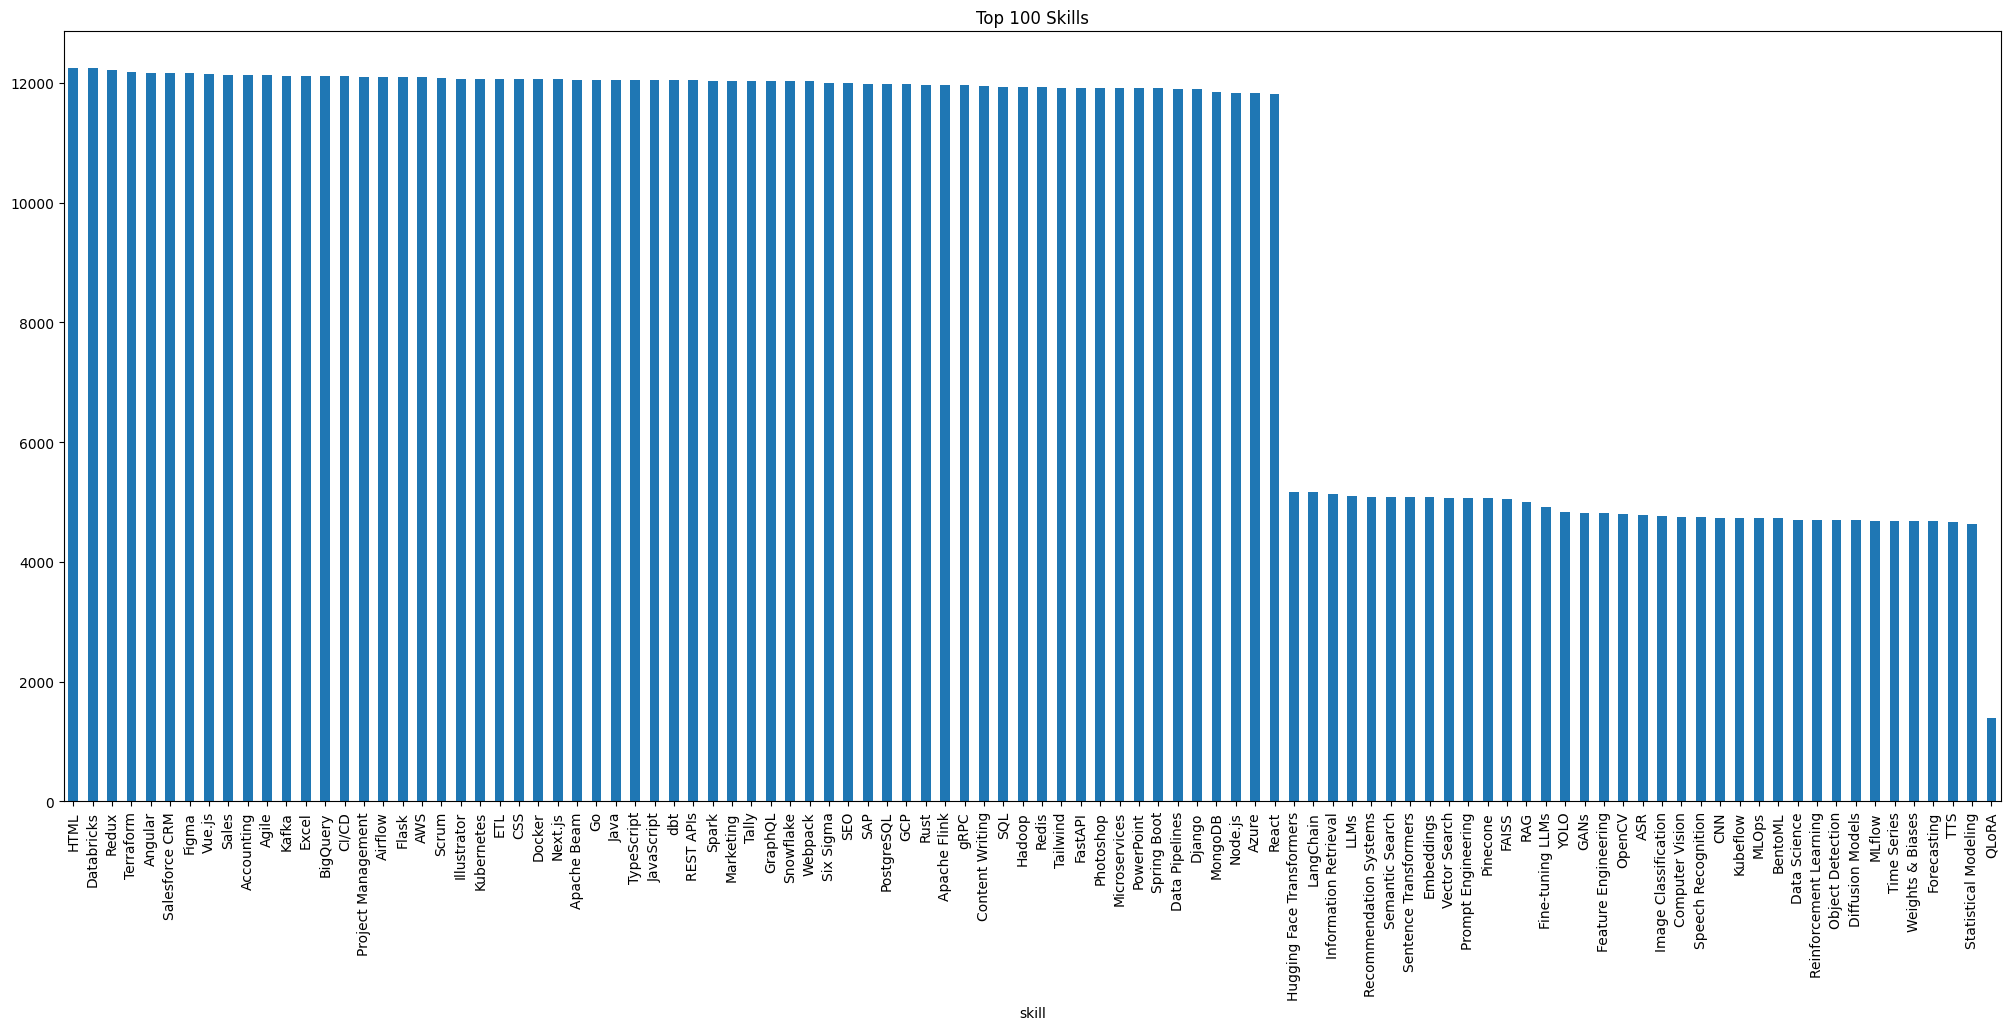

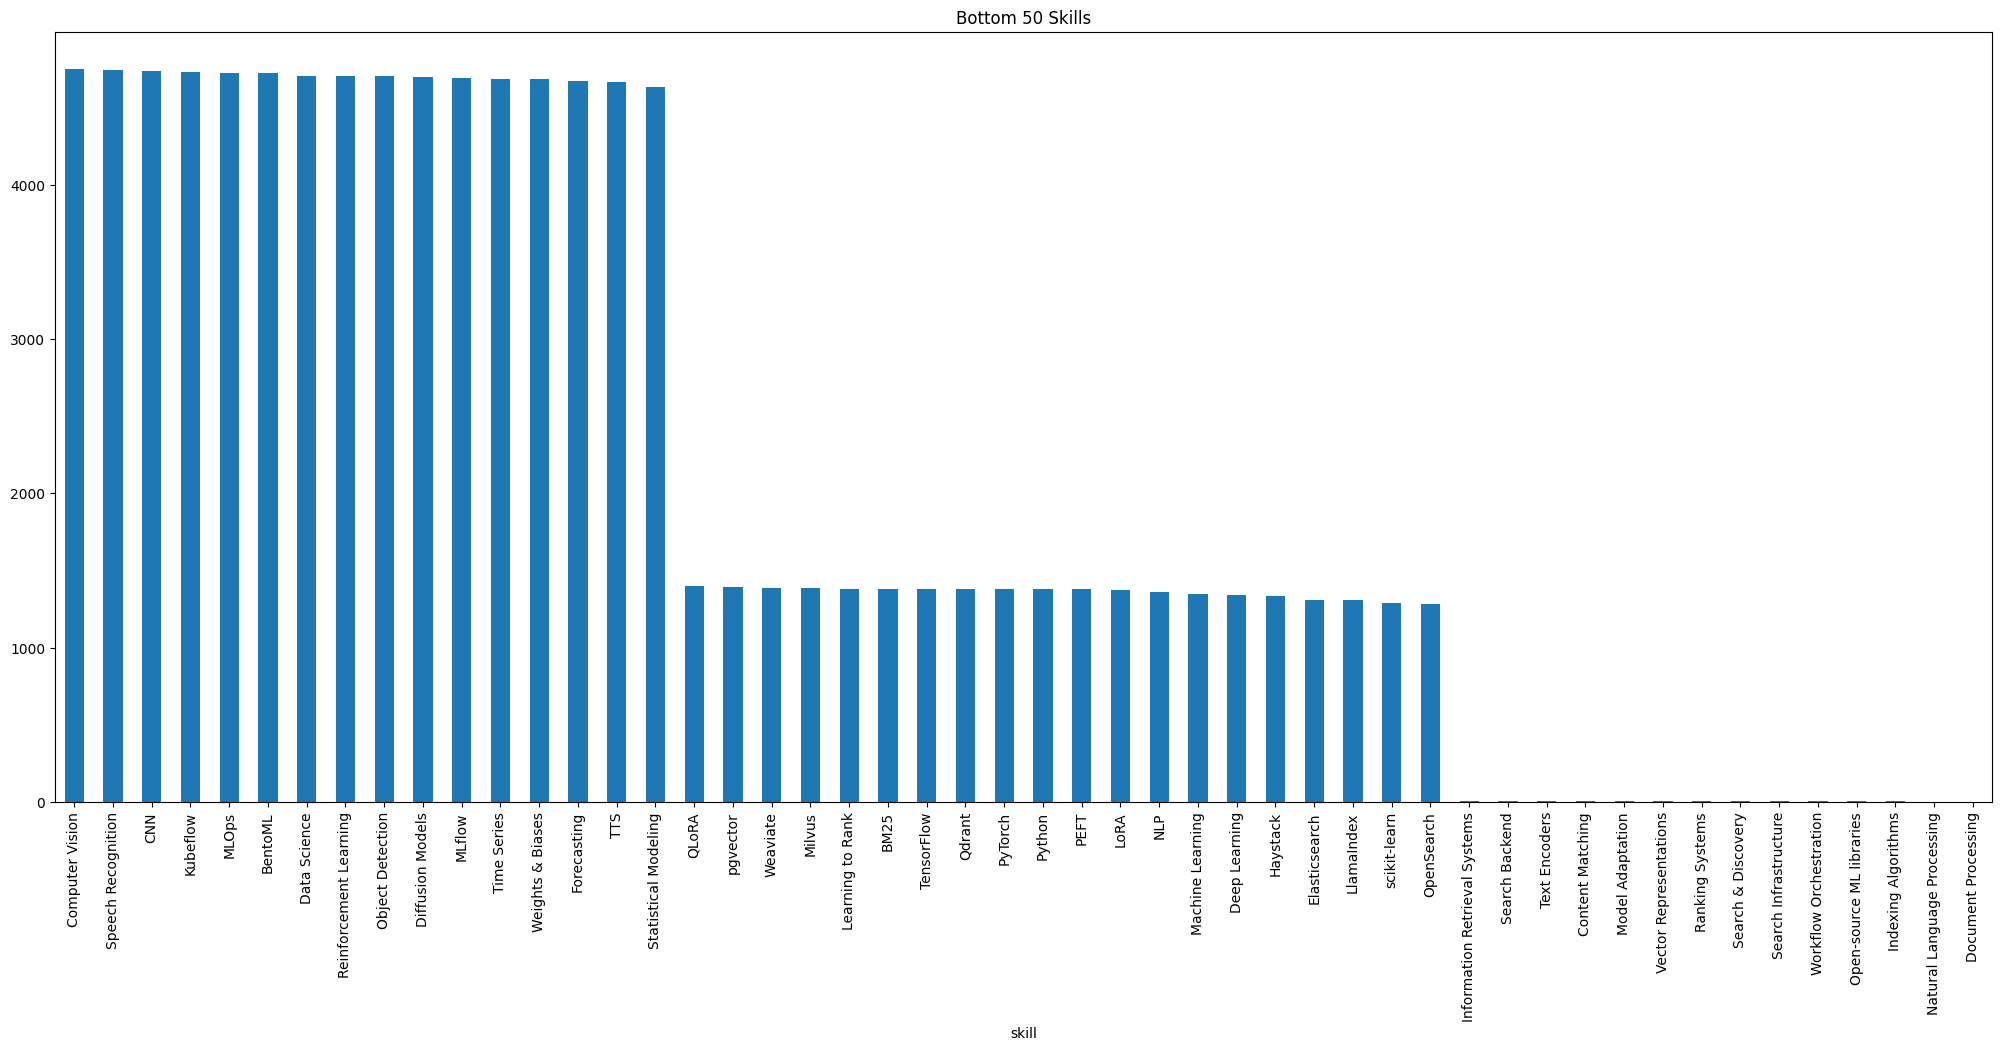

In [34]:
plt.figure(figsize=(25,10))
skills_df["skill"].value_counts().head(100).plot(kind="bar")
plt.title("Top 100 Skills")
plt.show()

plt.figure(figsize=(25,10))
skills_df["skill"].value_counts().tail(50).plot(kind="bar")
plt.title("Bottom 50 Skills")
plt.show()


In [46]:
career_months = {}

for c in candidates:

    total = sum(
        job["duration_months"]
        for job in c["career_history"]
    )

    career_months[c["candidate_id"]] = total
    
results = []

for c in candidates:

    claimed = (
        c["profile"]["years_of_experience"]
        * 12
    )

    actual = career_months[
        c["candidate_id"]
    ]

    diff = claimed - actual

    results.append({
        "candidate_id": c["candidate_id"],
        "claimed_months": claimed,
        "actual_months": actual,
        "difference": diff
    })
    
results_df = pd.DataFrame(results)
with pd.option_context('display.max_rows', None):
    print(results_df.head(50))

    candidate_id  claimed_months  actual_months  difference
0   CAND_0000001            82.8             82         0.8
1   CAND_0000002           150.0            149         1.0
2   CAND_0000003            13.2             13         0.2
3   CAND_0000004            45.6             44         1.6
4   CAND_0000005           132.0            130         2.0
5   CAND_0000006            72.0             71         1.0
6   CAND_0000007            66.0             65         1.0
7   CAND_0000008            43.2             43         0.2
8   CAND_0000009           132.0            131         1.0
9   CAND_0000010            55.2             55         0.2
10  CAND_0000011            24.0             23         1.0
11  CAND_0000012            13.2             13         0.2
12  CAND_0000013            13.2             13         0.2
13  CAND_0000014           100.8            100         0.8
14  CAND_0000015            64.8             64         0.8
15  CAND_0000016            63.6        

drop this candidates 


In [52]:

negative_candidates = []

for r in results:
    if r["difference"] < 0:
        negative_candidates.append(r)
        # print(r)
        
negative_candidates_df = pd.DataFrame(negative_candidates)
negative_candidates_df

,candidate_id,claimed_months,actual_months,difference
0,CAND_0001610,36.0,61,-25.0
1,CAND_0007353,118.8,251,-132.2
2,CAND_0008960,123.6,271,-147.4
3,CAND_0010294,96.0,220,-124.0
4,CAND_0018515,102.0,211,-109.0
5,CAND_0019480,33.6,87,-53.4
6,CAND_0035104,66.0,162,-96.0
7,CAND_0037000,32.4,75,-42.6
8,CAND_0037539,58.8,115,-56.2
9,CAND_0039521,36.0,59,-23.0


In [64]:
from datetime import datetime

bad_candidates = []

for c in candidates:

    signup = datetime.strptime(
        c["redrob_signals"]["signup_date"],
        "%Y-%m-%d"
    )

    last_active = datetime.strptime(
        c["redrob_signals"]["last_active_date"],
        "%Y-%m-%d"
    )

    if signup > last_active:

        bad_candidates.append(
            {
                "candidate_id": c["candidate_id"],
                "signup_date": c["redrob_signals"]["signup_date"],
                "last_active_date": c["redrob_signals"]["last_active_date"]
            }
        )
        
bad_candidates_df = pd.DataFrame(bad_candidates)
print("Total bad candidates : ", bad_candidates_df.shape[0])
bad_candidates_df
# with pd.option_context('display.max_rows', None):
#     print(bad_candidates_df.sum())

Total bad candidates :  7496


,candidate_id,signup_date,last_active_date
0,CAND_0000006,2026-04-26,2026-02-28
1,CAND_0000021,2026-02-10,2025-11-21
2,CAND_0000066,2026-05-08,2026-03-13
3,CAND_0000073,2026-04-27,2026-02-06
4,CAND_0000077,2026-02-14,2025-12-10
...,...,...,...
7491,CAND_0099917,2026-01-07,2025-09-29
7492,CAND_0099941,2026-04-17,2026-02-01
7493,CAND_0099961,2026-03-13,2025-10-26
7494,CAND_0099988,2025-10-17,2025-10-11
